Notebook 02: Dataset Exploration & Analysis

In [1]:
from pathlib import Path
from collections import Counter
from PIL import Image

import os
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
print("Libaries Install")

Libaries Install


In [8]:
PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = PROJECT_ROOT / "dataset" / "PlantVillage"

TRAIN_PATH = DATASET_ROOT / "train"
VAL_PATH = DATASET_ROOT / "val"

print("Dataset :", DATASET_ROOT)
print("Train   :", TRAIN_PATH)
print("Val     :", VAL_PATH)

Dataset : o:\Hackthons\KrishiOS\ai\dataset\PlantVillage
Train   : o:\Hackthons\KrishiOS\ai\dataset\PlantVillage\train
Val     : o:\Hackthons\KrishiOS\ai\dataset\PlantVillage\val


In [9]:
assert DATASET_ROOT.exists(), "Dataset folder not found!"
assert TRAIN_PATH.exists(), "Train folder not found!"
assert VAL_PATH.exists(), "Validation folder not found!"

print("✅ Dataset Verified")

✅ Dataset Verified


In [10]:
train_classes = sorted(
    [
        folder.name
        for folder in TRAIN_PATH.iterdir()
        if folder.is_dir()
    ]
)

val_classes = sorted(
    [
        folder.name
        for folder in VAL_PATH.iterdir()
        if folder.is_dir()
    ]
)

print("Train Classes      :", len(train_classes))
print("Validation Classes :", len(val_classes))

Train Classes      : 38
Validation Classes : 38


In [11]:
assert train_classes == val_classes

print("✅ Train and Validation classes match.")

✅ Train and Validation classes match.


In [12]:
for i, cls in enumerate(train_classes, start=1):
    print(f"{i:02d}. {cls}")

01. Apple___Apple_scab
02. Apple___Black_rot
03. Apple___Cedar_apple_rust
04. Apple___healthy
05. Blueberry___healthy
06. Cherry_(including_sour)___Powdery_mildew
07. Cherry_(including_sour)___healthy
08. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
09. Corn_(maize)___Common_rust_
10. Corn_(maize)___Northern_Leaf_Blight
11. Corn_(maize)___healthy
12. Grape___Black_rot
13. Grape___Esca_(Black_Measles)
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
15. Grape___healthy
16. Orange___Haunglongbing_(Citrus_greening)
17. Peach___Bacterial_spot
18. Peach___healthy
19. Pepper,_bell___Bacterial_spot
20. Pepper,_bell___healthy
21. Potato___Early_blight
22. Potato___Late_blight
23. Potato___healthy
24. Raspberry___healthy
25. Soybean___healthy
26. Squash___Powdery_mildew
27. Strawberry___Leaf_scorch
28. Strawberry___healthy
29. Tomato___Bacterial_spot
30. Tomato___Early_blight
31. Tomato___Late_blight
32. Tomato___Leaf_Mold
33. Tomato___Septoria_leaf_spot
34. Tomato___Spider_mites Two-spotte

In [15]:
train_counts = {}
val_counts = {}

for cls in train_classes:

    train_counts[cls] = len(list((TRAIN_PATH / cls).glob("*")))

    val_counts[cls] = len(list((VAL_PATH / cls).glob("*")))

In [16]:
df = pd.DataFrame({

    "Class": train_classes,

    "Train Images": [train_counts[c] for c in train_classes],

    "Validation Images": [val_counts[c] for c in train_classes]

})

df["Total Images"] = df["Train Images"] + df["Validation Images"]

df

,Class,Train Images,Validation Images,Total Images
0,Apple___Apple_scab,504,126,630
1,Apple___Black_rot,496,125,621
2,Apple___Cedar_apple_rust,220,55,275
3,Apple___healthy,1316,329,1645
4,Blueberry___healthy,1202,300,1502
5,Cherry_(including_sour)___Powdery_mildew,842,210,1052
6,Cherry_(including_sour)___healthy,684,170,854
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410,103,513
8,Corn_(maize)___Common_rust_,953,239,1192
9,Corn_(maize)___Northern_Leaf_Blight,788,197,985


In [ ]:
print("="*50)

print("Total Classes :", len(df))

print("Training Images :", df["Train Images"].sum())

print("Validation Images :", df["Validation Images"].sum())

print("Total Images :", df["Total Images"].sum())

print("="*50)

Total Classes : 38
Training Images : 43444
Validation Images : 10861
Total Images : 54305


In [18]:
print("Largest Class")

display(df.loc[df["Total Images"].idxmax()])

print()

print("Smallest Class")

display(df.loc[df["Total Images"].idxmin()])

Largest Class


Class                Orange___Haunglongbing_(Citrus_greening)
Train Images                                             4405
Validation Images                                        1102
Total Images                                             5507
Name: 15, dtype: object


Smallest Class


Class                Potato___healthy
Train Images                      121
Validation Images                  31
Total Images                      152
Name: 22, dtype: object

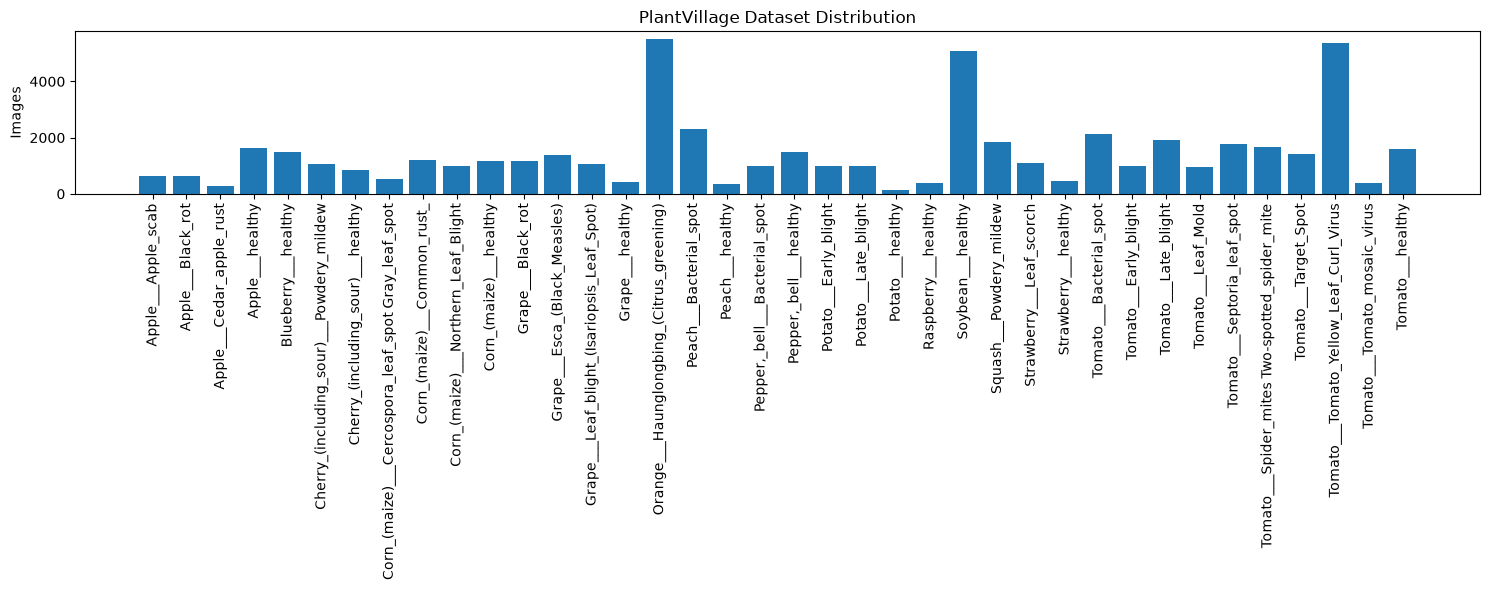

In [19]:
plt.figure(figsize=(15,6))

plt.bar(df["Class"], df["Total Images"])

plt.xticks(rotation=90)

plt.ylabel("Images")

plt.title("PlantVillage Dataset Distribution")

plt.tight_layout()

plt.show()

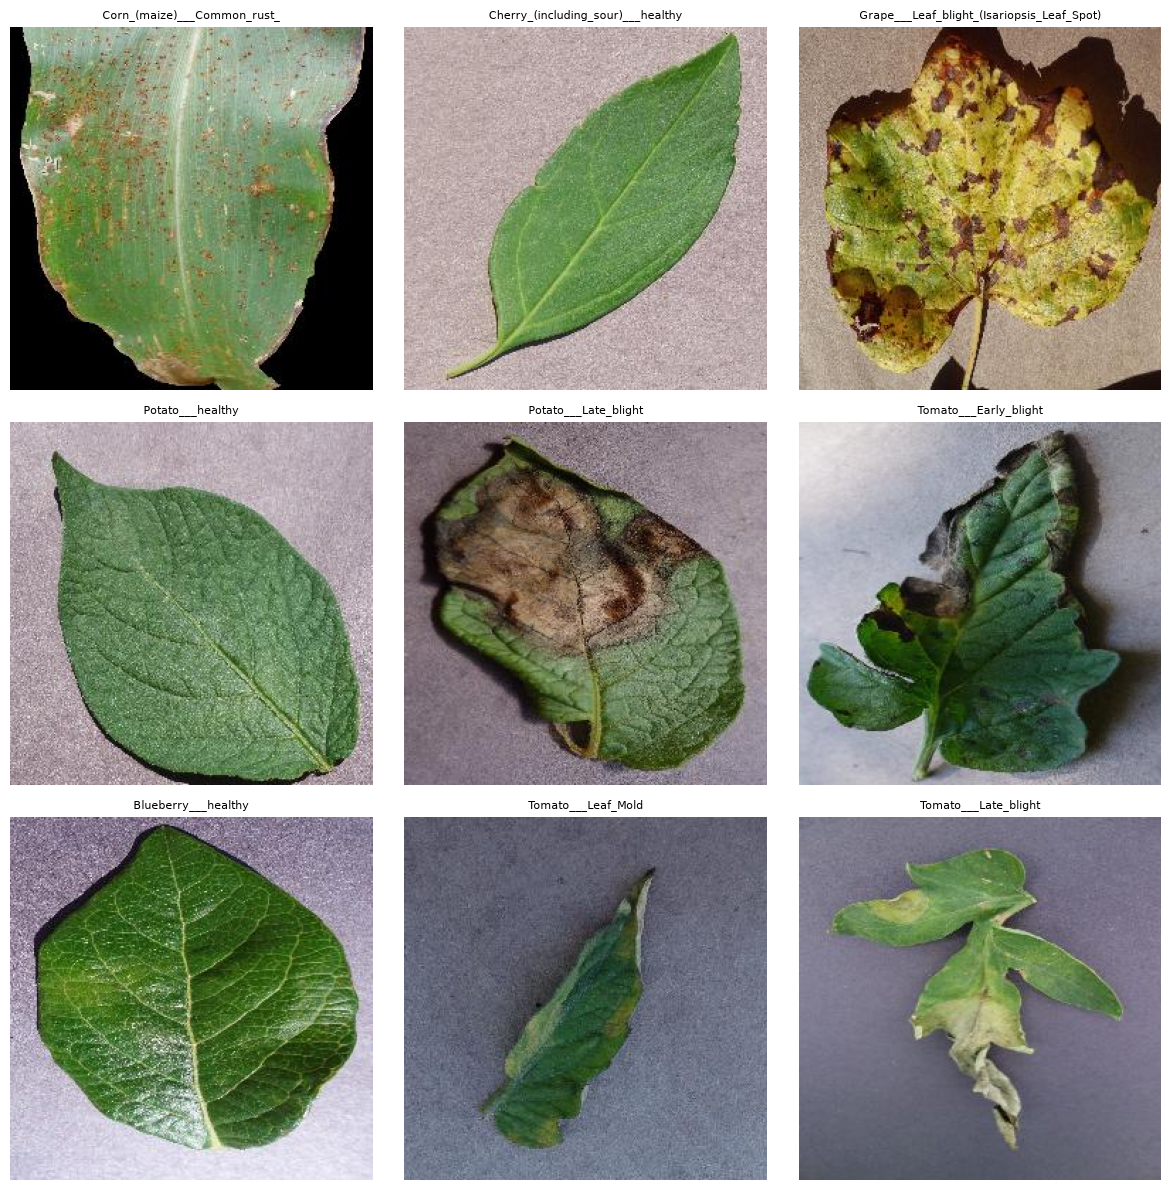

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(12,12))

for ax in axes.flat:

    cls = random.choice(train_classes)

    img_path = random.choice(
        list((TRAIN_PATH / cls).glob("*"))
    )

    img = Image.open(img_path)

    ax.imshow(img)

    ax.set_title(cls, fontsize=8)

    ax.axis("off")

plt.tight_layout()

plt.show()

In [22]:
sizes = []

for cls in train_classes:

    for img_path in (TRAIN_PATH / cls).glob("*"):

        img = Image.open(img_path)

        sizes.append(img.size)

sizes = np.array(sizes)

In [23]:
print("Average Width :", sizes[:,0].mean())

print("Average Height :", sizes[:,1].mean())

print("Minimum Width :", sizes[:,0].min())

print("Maximum Width :", sizes[:,0].max())

Average Width : 256.0
Average Height : 256.0
Minimum Width : 256
Maximum Width : 256


In [24]:
modes = Counter()

for cls in train_classes:

    for img_path in (TRAIN_PATH / cls).glob("*"):

        img = Image.open(img_path)

        modes[img.mode] += 1

print(modes)

Counter({'RGB': 43443, 'RGBA': 1})


In [25]:
bad_images = []

for cls in train_classes:

    for img_path in (TRAIN_PATH / cls).glob("*"):

        try:

            Image.open(img_path).verify()

        except Exception:

            bad_images.append(img_path)

print("Corrupt Images :", len(bad_images))

Corrupt Images : 0


In [26]:
summary = pd.DataFrame({

    "Metric":[

        "Classes",

        "Training Images",

        "Validation Images",

        "Total Images",

        "Corrupt Images"

    ],

    "Value":[

        len(df),

        df["Train Images"].sum(),

        df["Validation Images"].sum(),

        df["Total Images"].sum(),

        len(bad_images)

    ]

})

summary

,Metric,Value
0,Classes,38
1,Training Images,43444
2,Validation Images,10861
3,Total Images,54305
4,Corrupt Images,0
